# MODELO B: Predicción de Días de Atraso

**Objetivo:** Predecir cuántos días de atraso tendrá un envío al momento del despacho (regresión).

**Target:** `delay_days = Days_for_shipping_(real) - Days_for_shipment_(scheduled)`
- delay > 0 → tardanza (días de atraso)
- delay = 0 → en fecha
- delay < 0 → adelantado

**Diferencia con Modelo A (clasificación):** 
- Modelo A predice SI/NO habrá tardanza (Late_delivery_risk)
- Modelo B predice CUÁNTOS días de atraso (magnitud del problema)

## 0. Imports y Configuración

Librerías para regresión, evaluación y visualización.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Modelo
try:
    import lightgbm as lgb
except ModuleNotFoundError:
    import sys
    import subprocess
    print('Instalando lightgbm...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm'])
    import lightgbm as lgb

# Métricas de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Librerías cargadas')
print(f'LightGBM version: {lgb.__version__}')

✓ Librerías cargadas
LightGBM version: 4.6.0


---

## SECCIÓN 1 — CARGA Y PREPARACIÓN

Cargar datos, filtrar universo y crear el target de días de atraso.

---

### Cargar Dataset Limpio

Cargar el dataset limpio generado en el Paso 2.

In [15]:
print('='*70)
print(' '*15 + 'CARGA DE DATOS')
print('='*70)

# Cargar dataset limpio
data_dir = Path('../data/processed')
df = pd.read_csv(data_dir / 'DataCoSupplyChainDataset_clean.csv')

print(f'\n✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nPrimeras columnas: {list(df.columns[:15])}')

               CARGA DE DATOS

✓ Dataset cargado: 180,519 filas × 35 columnas

Primeras columnas: ['Type', 'Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Id', 'Customer_Segment', 'Customer_State', 'Department_Id']


### Parseo de Fecha y Filtro de Universo

Parsear shipping_date y filtrar envíos cancelados (mismo universo que modelos anteriores).

In [16]:
print('\n=== PREPARACIÓN DE DATOS ===\n')

# Parsear shipping_date
df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'], errors='coerce')
nulos_fecha = df['shipping_date_(DateOrders)'].isna().sum()

if nulos_fecha > 0:
    print(f'⚠️ Eliminando {nulos_fecha:,} filas sin fecha válida')
    df = df.dropna(subset=['shipping_date_(DateOrders)'])

print(f'✓ Fechas parseadas: {df["shipping_date_(DateOrders)"].min().date()} a {df["shipping_date_(DateOrders)"].max().date()}')

# Filtrar cancelados (universo consistente)
if 'Delivery_Status' in df.columns:
    filas_antes = len(df)
    df = df[~df['Delivery_Status'].str.contains('cancel', case=False, na=False)].copy()
    print(f'✓ Filtro cancelados: {filas_antes:,} → {len(df):,} filas (-{filas_antes - len(df):,})')
else:
    print('⚠️ Columna Delivery_Status no encontrada - no se aplicó filtro')

print(f'\n✓ Dataset preparado: {len(df):,} filas')


=== PREPARACIÓN DE DATOS ===

✓ Fechas parseadas: 2015-01-03 a 2018-02-06
✓ Filtro cancelados: 180,519 → 172,765 filas (-7,754)

✓ Dataset preparado: 172,765 filas


### Crear Target: delay_days

Calcular días de atraso como diferencia entre real y programado.

In [17]:
print('\n=== CREACIÓN DEL TARGET: delay_days ===\n')

# Verificar que existan las columnas necesarias
required_cols = ['Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f'❌ ERROR: Columnas faltantes: {missing_cols}')
    raise ValueError(f'No se puede calcular delay_days sin: {missing_cols}')

# Calcular delay_days
df['delay_days'] = df['Days_for_shipping_(real)'] - df['Days_for_shipment_(scheduled)']

# Opcional: delay solo positivo (atraso únicamente)
df['delay_pos'] = df['delay_days'].clip(lower=0)

print(f'✓ Target creado: delay_days')
print(f'\n📊 Estadísticas de delay_days:')
print(f'   Media:    {df["delay_days"].mean():.2f} días')
print(f'   Mediana:  {df["delay_days"].median():.2f} días')
print(f'   Desv.Est: {df["delay_days"].std():.2f} días')
print(f'   Min:      {df["delay_days"].min():.0f} días')
print(f'   Max:      {df["delay_days"].max():.0f} días')

# Eliminar nulos en target
nulos_target = df['delay_days'].isna().sum()
if nulos_target > 0:
    print(f'\n⚠️ Eliminando {nulos_target:,} filas con delay_days nulo')
    df = df.dropna(subset=['delay_days'])

print(f'\n✓ Dataset final con target: {len(df):,} filas')


=== CREACIÓN DEL TARGET: delay_days ===

✓ Target creado: delay_days

📊 Estadísticas de delay_days:
   Media:    0.57 días
   Mediana:  1.00 días
   Desv.Est: 1.49 días
   Min:      -2 días
   Max:      4 días

✓ Dataset final con target: 172,765 filas


### Distribución del Target

Analizar la distribución de días de atraso para entender el problema.


=== DISTRIBUCIÓN DE delay_days ===

📊 Percentiles de delay_days:
   P  0:   -2.0 días
   P 10:   -2.0 días
   P 25:    0.0 días
   P 50:    1.0 días
   P 75:    1.0 días
   P 90:    2.0 días
   P 95:    3.0 días
   P 99:    4.0 días
   P100:    4.0 días

📦 Clasificación de envíos:
   Adelantados (delay < 0): 41,592 (24.1%)
   En fecha (delay = 0):    32,196 (18.6%)
   Atrasados (delay > 0):   98,977 (57.3%)

⚠️ Outliers detectados (criterio 3×IQR):
   Extremos bajos (< -3.0):  0
   Extremos altos (> 4.0): 0
   Total outliers: 0 (0.00%)
   → No se eliminan, pero se reportan para análisis


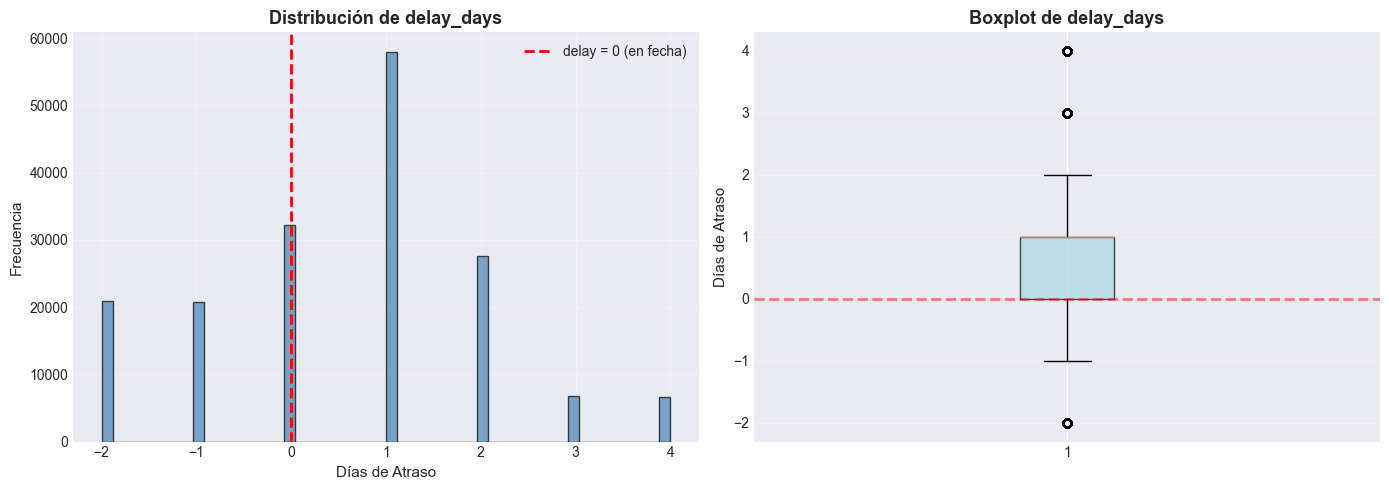

In [18]:
print('\n=== DISTRIBUCIÓN DE delay_days ===\n')

# Percentiles
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
delay_percentiles = df['delay_days'].quantile([p/100 for p in percentiles])

print(f'📊 Percentiles de delay_days:')
for p, val in zip(percentiles, delay_percentiles):
    print(f'   P{p:3d}: {val:6.1f} días')

# Clasificación por tipo
n_adelantados = (df['delay_days'] < 0).sum()
n_en_fecha = (df['delay_days'] == 0).sum()
n_atrasados = (df['delay_days'] > 0).sum()

total = len(df)
print(f'\n📦 Clasificación de envíos:')
print(f'   Adelantados (delay < 0): {n_adelantados:,} ({n_adelantados/total*100:.1f}%)')
print(f'   En fecha (delay = 0):    {n_en_fecha:,} ({n_en_fecha/total*100:.1f}%)')
print(f'   Atrasados (delay > 0):   {n_atrasados:,} ({n_atrasados/total*100:.1f}%)')

# Identificar outliers (sin eliminar)
q1 = df['delay_days'].quantile(0.25)
q3 = df['delay_days'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr

outliers_lower = (df['delay_days'] < lower_bound).sum()
outliers_upper = (df['delay_days'] > upper_bound).sum()

print(f'\n⚠️ Outliers detectados (criterio 3×IQR):')
print(f'   Extremos bajos (< {lower_bound:.1f}):  {outliers_lower:,}')
print(f'   Extremos altos (> {upper_bound:.1f}): {outliers_upper:,}')
print(f'   Total outliers: {outliers_lower + outliers_upper:,} ({(outliers_lower + outliers_upper)/total*100:.2f}%)')
print(f'   → No se eliminan, pero se reportan para análisis')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['delay_days'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='delay = 0 (en fecha)')
axes[0].set_xlabel('Días de Atraso', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de delay_days', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['delay_days'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].set_ylabel('Días de Atraso', fontsize=11)
axes[1].set_title('Boxplot de delay_days', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## SECCIÓN 2 — SPLIT TEMPORAL

Particionar datos por fecha de despacho (train/test temporal).

---

### Split 80/20 Temporal

Usar el mismo split temporal que en modelos anteriores.

In [19]:
print('='*70)
print(' '*15 + 'SPLIT TEMPORAL')
print('='*70)

# Ordenar por fecha
df_sorted = df.sort_values('shipping_date_(DateOrders)').reset_index(drop=True)

# Calcular punto de corte (80/20)
split_idx = int(len(df_sorted) * 0.8)

# Dividir train/test
train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

print(f'\n📊 TRAIN SET:')
print(f'   Filas: {len(train):,} ({len(train)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha: {train["shipping_date_(DateOrders)"].min().date()} → {train["shipping_date_(DateOrders)"].max().date()}')
print(f'   delay_days media: {train["delay_days"].mean():.2f} días')
print(f'   delay_days std:   {train["delay_days"].std():.2f} días')

print(f'\n📊 TEST SET:')
print(f'   Filas: {len(test):,} ({len(test)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha: {test["shipping_date_(DateOrders)"].min().date()} → {test["shipping_date_(DateOrders)"].max().date()}')
print(f'   delay_days media: {test["delay_days"].mean():.2f} días')
print(f'   delay_days std:   {test["delay_days"].std():.2f} días')

print('\n✓ Split temporal completado')

               SPLIT TEMPORAL

📊 TRAIN SET:
   Filas: 138,212 (80.0%)
   Fecha: 2015-01-03 → 2017-04-25
   delay_days media: 0.57 días
   delay_days std:   1.49 días

📊 TEST SET:
   Filas: 34,553 (20.0%)
   Fecha: 2017-04-25 → 2018-02-06
   delay_days media: 0.56 días
   delay_days std:   1.49 días

✓ Split temporal completado


---

## SECCIÓN 3 — BASELINES DE REGRESIÓN

Construir modelos simples de referencia (reglas sin ML).

---

### Baseline 0: Media Global

Predecir la media de delay_days del train para todos los casos de test.

In [20]:
print('='*70)
print(' '*15 + 'BASELINE 0: MEDIA GLOBAL')
print('='*70)

# Calcular media en TRAIN
delay_mean_train = train['delay_days'].mean()

# Predecir esta media para todo el TEST
test['pred_baseline0'] = delay_mean_train

# Evaluar
y_true = test['delay_days'].values
y_pred_b0 = test['pred_baseline0'].values

mae_b0 = mean_absolute_error(y_true, y_pred_b0)
rmse_b0 = np.sqrt(mean_squared_error(y_true, y_pred_b0))
r2_b0 = r2_score(y_true, y_pred_b0)

print(f'\n✓ Baseline 0 (media global): {delay_mean_train:.2f} días')
print(f'\n📊 Métricas en TEST:')
print(f'   MAE:  {mae_b0:.2f} días (error absoluto medio)')
print(f'   RMSE: {rmse_b0:.2f} días (error cuadrático medio)')
print(f'   R²:   {r2_b0:.4f}')

               BASELINE 0: MEDIA GLOBAL

✓ Baseline 0 (media global): 0.57 días

📊 Métricas en TEST:
   MAE:  1.20 días (error absoluto medio)
   RMSE: 1.49 días (error cuadrático medio)
   R²:   -0.0000


### Baseline 1: Media por Segmento (Shipping_Mode × Order_Region)

Predecir media histórica por grupo, similar al Baseline 2 de clasificación.

In [21]:
print('='*70)
print(' '*15 + 'BASELINE 1: MEDIA POR SEGMENTO')
print('='*70)

# Calcular medias históricas en TRAIN
print('\n📊 Calculando medias históricas en TRAIN...')

# Media global (fallback)
global_delay_mean = train['delay_days'].mean()
print(f'\n   Media global: {global_delay_mean:.2f} días')

# Media por Shipping_Mode
mode_delay_means = train.groupby('Shipping_Mode')['delay_days'].mean().to_dict()
print(f'   Medias por Shipping_Mode: {len(mode_delay_means)} grupos')

# Media por (Shipping_Mode, Order_Region)
group_delay_means = train.groupby(['Shipping_Mode', 'Order_Region'])['delay_days'].mean().to_dict()
print(f'   Medias por (Mode, Region): {len(group_delay_means)} grupos')

# Aplicar predicciones en TEST con fallbacks
print('\n🎯 Aplicando predicciones en TEST con fallbacks...')

def get_baseline1_pred(row):
    """Obtener predicción baseline 1 con jerarquía de fallbacks"""
    key_group = (row['Shipping_Mode'], row['Order_Region'])
    key_mode = row['Shipping_Mode']
    
    # Prior idad: media de grupo → media de modo → media global
    if key_group in group_delay_means:
        return group_delay_means[key_group]
    elif key_mode in mode_delay_means:
        return mode_delay_means[key_mode]
    else:
        return global_delay_mean

test['pred_baseline1'] = test.apply(get_baseline1_pred, axis=1)

# Evaluar
y_pred_b1 = test['pred_baseline1'].values

mae_b1 = mean_absolute_error(y_true, y_pred_b1)
rmse_b1 = np.sqrt(mean_squared_error(y_true, y_pred_b1))
r2_b1 = r2_score(y_true, y_pred_b1)

print(f'\n✓ Baseline 1 reconstruido en TEST')
print(f'\n📊 Métricas en TEST:')
print(f'   MAE:  {mae_b1:.2f} días')
print(f'   RMSE: {rmse_b1:.2f} días')
print(f'   R²:   {r2_b1:.4f}')

print(f'\n📈 Mejora vs Baseline 0:')
print(f'   MAE:  {mae_b0 - mae_b1:+.2f} días ({(mae_b0 - mae_b1)/mae_b0*100:+.1f}%)')
print(f'   RMSE: {rmse_b0 - rmse_b1:+.2f} días ({(rmse_b0 - rmse_b1)/rmse_b0*100:+.1f}%)')

               BASELINE 1: MEDIA POR SEGMENTO

📊 Calculando medias históricas en TRAIN...

   Media global: 0.57 días
   Medias por Shipping_Mode: 4 grupos
   Medias por (Mode, Region): 92 grupos

🎯 Aplicando predicciones en TEST con fallbacks...

✓ Baseline 1 reconstruido en TEST

📊 Métricas en TEST:
   MAE:  0.98 días
   RMSE: 1.27 días
   R²:   0.2797

📈 Mejora vs Baseline 0:
   MAE:  +0.22 días (+18.2%)
   RMSE: +0.23 días (+15.1%)


### Tabla Comparativa de Baselines

Consolidar métricas de ambos baselines.

In [22]:
print('\n=== TABLA COMPARATIVA DE BASELINES ===\n')

# Crear tabla de comparación
baselines_comparison = pd.DataFrame({
    'Modelo': ['Baseline 0 (media global)', 'Baseline 1 (media por segmento)'],
    'MAE': [mae_b0, mae_b1],
    'RMSE': [rmse_b0, rmse_b1],
    'R2': [r2_b0, r2_b1]
})

print(baselines_comparison.to_string(index=False))

# Identificar mejor baseline
mejor_baseline = 'Baseline 1' if mae_b1 < mae_b0 else 'Baseline 0'
print(f'\n✓ Mejor baseline: {mejor_baseline} (menor MAE)')


=== TABLA COMPARATIVA DE BASELINES ===

                         Modelo    MAE   RMSE      R2
      Baseline 0 (media global) 1.2042 1.4921 -0.0000
Baseline 1 (media por segmento) 0.9846 1.2663  0.2797

✓ Mejor baseline: Baseline 1 (menor MAE)


---

## SECCIÓN 4 — MODELO B: LIGHTGBM REGRESSOR

Entrenar modelo de regresión para predecir **delay_days** (cuántos días de atraso).

---

### 4.1 Definición de Features

Usamos la **misma lista de features** que en Modelo A (sin fugas).

In [23]:
print('='*70)
print(' '*15 + 'MODELO B: LIGHTGBM REGRESSOR')
print('='*70)

# Features EXACTAS del Modelo A (sin variables de fuga)
features_modelo_b = [
    # Temporales (shipping_date → año, mes, day_of_week)
    'shipping_year',
    'shipping_month',
    'shipping_day_of_week',
    
    # Pedido
    'Days_for_shipment_(scheduled)',
    'Benefit_per_order',
    'Sales_per_customer',
    'Category_Id',
    'Product_Price',
    
    # Geografía
    'Order_Region',
    'Order_Country',
    'Order_State',
    'Order_City',
    'Market',
    
    # Cliente
    'Customer_Segment',
    
    # Logística
    'Shipping_Mode',
    'Order_Item_Quantity'
]

print(f'\n✓ Total de features a usar: {len(features_modelo_b)}')
print(f'\n📦 Features seleccionadas:')
for i, col in enumerate(features_modelo_b, 1):
    print(f'   {i:2d}. {col}')

# Verificar disponibilidad
missing_in_df = [c for c in features_modelo_b if c not in df.columns]
if missing_in_df:
    print(f'\n⚠ ADVERTENCIA: Features no encontradas: {missing_in_df}')
else:
    print('\n✓ Todas las features están presentes en el DataFrame')

               MODELO B: LIGHTGBM REGRESSOR

✓ Total de features a usar: 16

📦 Features seleccionadas:
    1. shipping_year
    2. shipping_month
    3. shipping_day_of_week
    4. Days_for_shipment_(scheduled)
    5. Benefit_per_order
    6. Sales_per_customer
    7. Category_Id
    8. Product_Price
    9. Order_Region
   10. Order_Country
   11. Order_State
   12. Order_City
   13. Market
   14. Customer_Segment
   15. Shipping_Mode
   16. Order_Item_Quantity

⚠ ADVERTENCIA: Features no encontradas: ['shipping_year', 'shipping_month', 'shipping_day_of_week', 'Product_Price']


### 4.2 Feature Engineering Temporal

Agregar features temporales extraídas de `shipping_date_(DateOrders)`.

In [24]:
print('\n📅 Creando features temporales...')

# Asegurar que shipping_date sea datetime
if 'shipping_date_(DateOrders)' not in train.columns:
    print('⚠ ADVERTENCIA: shipping_date_(DateOrders) no está en train/test')
    print('  Creándola desde df original...')
    
    # Agregar shipping_date a train y test
    date_col = pd.to_datetime(df['shipping_date_(DateOrders)'])
    train['shipping_date_(DateOrders)'] = date_col.loc[train.index]
    test['shipping_date_(DateOrders)'] = date_col.loc[test.index]

# Crear features temporales
for subset, name in [(train, 'TRAIN'), (test, 'TEST')]:
    subset['shipping_year'] = pd.to_datetime(subset['shipping_date_(DateOrders)']).dt.year
    subset['shipping_month'] = pd.to_datetime(subset['shipping_date_(DateOrders)']).dt.month
    subset['shipping_day_of_week'] = pd.to_datetime(subset['shipping_date_(DateOrders)']).dt.dayofweek
    print(f'   ✓ Features temporales creadas en {name}')

print('\n✓ Feature engineering temporal completado')


📅 Creando features temporales...
   ✓ Features temporales creadas en TRAIN
   ✓ Features temporales creadas en TEST

✓ Feature engineering temporal completado


### 4.3 Preprocesamiento (Imputación y Encoding)

Preprocesar features numéricas y categóricas.

In [25]:
print('\n⚙ Preprocesando features...')

# Separar features y target
# Corregir nombres de columnas esperadas vs reales
feature_alias = {
    'Product_Price': 'Order_Item_Product_Price'
}
features_modelo_b = [feature_alias.get(c, c) for c in features_modelo_b]

# Validar que todas las features existan en train/test
missing_train = [c for c in features_modelo_b if c not in train.columns]
missing_test = [c for c in features_modelo_b if c not in test.columns]
if missing_train or missing_test:
    raise KeyError(
        f'Features faltantes. Train: {missing_train} | Test: {missing_test}'
    )

X_train = train[features_modelo_b].copy()
y_train = train['delay_days'].copy()

X_test = test[features_modelo_b].copy()
y_test = test['delay_days'].copy()

# Identificar columnas numéricas y categóricas
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'\n   Features numéricas: {len(numeric_features)}')
print(f'   Features categóricas: {len(categorical_features)}')

# Imputación numérica (mediana)
from sklearn.impute import SimpleImputer

imputer_num = SimpleImputer(strategy='median')
X_train[numeric_features] = imputer_num.fit_transform(X_train[numeric_features])
X_test[numeric_features] = imputer_num.transform(X_test[numeric_features])

# Imputación categórica (moda)
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[categorical_features] = imputer_cat.fit_transform(X_train[categorical_features])
X_test[categorical_features] = imputer_cat.transform(X_test[categorical_features])

# Label Encoding para categóricas
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit en train + test combinados para evitar categorías desconocidas
    combined = pd.concat([X_train[col], X_test[col]], axis=0)
    le.fit(combined)
    
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print('\n✓ Preprocesamiento completado')
print(f'   Train shape: {X_train.shape}')
print(f'   Test shape:  {X_test.shape}')


⚙ Preprocesando features...

   Features numéricas: 9
   Features categóricas: 7

✓ Preprocesamiento completado
   Train shape: (138212, 16)
   Test shape:  (34553, 16)


### 4.4 Entrenamiento de LightGBM Regressor

Entrenar modelo con objetivo de regresión.

In [26]:
print('\n🚀 Entrenando LightGBM Regressor...')

# Parámetros para regresión
params_modeloB = {
    'objective': 'regression',  # REGRESIÓN (no binary)
    'metric': 'rmse',  # Métrica: RMSE
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'random_state': 42
}

# Entrenar
modelo_b = lgb.LGBMRegressor(**params_modeloB, n_estimators=200)
modelo_b.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='rmse')

print('\n✓ Modelo B entrenado')


🚀 Entrenando LightGBM Regressor...

✓ Modelo B entrenado


### 4.5 Predicciones y Evaluación

Generar predicciones y comparar con baselines.

In [27]:
print('\n📊 Generando predicciones...')

# Predecir en TEST
test['pred_modeloB'] = modelo_b.predict(X_test)

# Evaluar
y_pred_mb = test['pred_modeloB'].values

mae_mb = mean_absolute_error(y_test, y_pred_mb)
rmse_mb = np.sqrt(mean_squared_error(y_test, y_pred_mb))
r2_mb = r2_score(y_test, y_pred_mb)

print(f'\n✓ Predicciones generadas')
print(f'\n📊 Métricas MODELO B en TEST:')
print(f'   MAE:  {mae_mb:.2f} días')
print(f'   RMSE: {rmse_mb:.2f} días')
print(f'   R²:   {r2_mb:.4f}')

print(f'\n📈 Mejora vs Baseline 0:')
print(f'   MAE:  {mae_b0 - mae_mb:+.2f} días ({(mae_b0 - mae_mb)/mae_b0*100:+.1f}%)')
print(f'   RMSE: {rmse_b0 - rmse_mb:+.2f} días ({(rmse_b0 - rmse_mb)/rmse_b0*100:+.1f}%)')

print(f'\n📈 Mejora vs Baseline 1:')
print(f'   MAE:  {mae_b1 - mae_mb:+.2f} días ({(mae_b1 - mae_mb)/mae_b1*100:+.1f}%)')
print(f'   RMSE: {rmse_b1 - rmse_mb:+.2f} días ({(rmse_b1 - rmse_mb)/rmse_b1*100:+.1f}%)')

# Mostrar 5 ejemplos
print('\n🔍 Ejemplos de predicciones (primeros 5):')
ejemplos = test[['delay_days', 'pred_modeloB']].head(5).copy()
ejemplos.columns = ['delay_real', 'delay_pred']
ejemplos['error_abs'] = (ejemplos['delay_real'] - ejemplos['delay_pred']).abs()
print(ejemplos.to_string(index=False))


📊 Generando predicciones...

✓ Predicciones generadas

📊 Métricas MODELO B en TEST:
   MAE:  0.99 días
   RMSE: 1.27 días
   R²:   0.2811

📈 Mejora vs Baseline 0:
   MAE:  +0.21 días (+17.7%)
   RMSE: +0.23 días (+15.2%)

📈 Mejora vs Baseline 1:
   MAE:  -0.01 días (-0.7%)
   RMSE: +0.00 días (+0.1%)

🔍 Ejemplos de predicciones (primeros 5):
 delay_real  delay_pred  error_abs
          1      0.0361     0.9639
          1      0.0446     0.9554
          2      2.0595     0.0595
          2      2.0060     0.0060
          2      2.0218     0.0218


### 4.6 Visualización: Predicho vs Real

Scatter plot para evaluar ajuste del modelo.


📈 Generando visualización: Predicho vs Real...



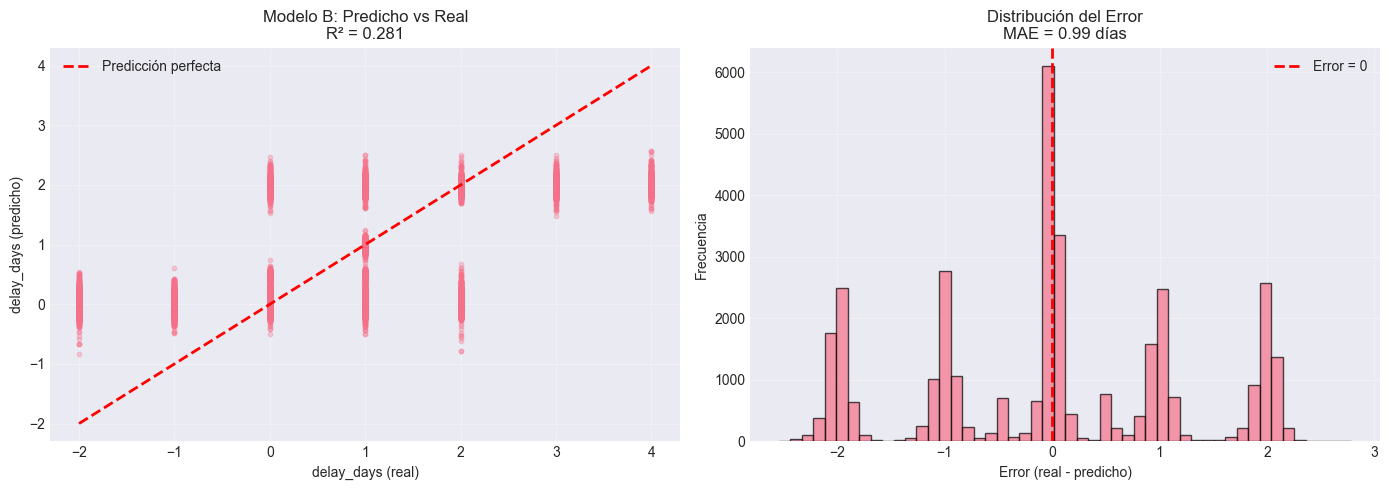

✓ Visualización completada


In [28]:
print('\n📈 Generando visualización: Predicho vs Real...\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter: pred vs real
axes[0].scatter(y_test, y_pred_mb, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('delay_days (real)')
axes[0].set_ylabel('delay_days (predicho)')
axes[0].set_title(f'Modelo B: Predicho vs Real\nR² = {r2_mb:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Distribución del error
error_mb = y_test - y_pred_mb
axes[1].hist(error_mb, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución del Error\nMAE = {mae_mb:.2f} días')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Visualización completada')

---

## SECCIÓN 5 — INTERPRETACIÓN

Entender qué features impulsan las predicciones de delay_days.

---

### 5.1 Feature Importance (Top 10)

Identificar variables más importantes para predecir días de atraso.

                    INTERPRETACIÓN

📊 Top 10 Features más importantes:

                      feature  importance
                   Order_City        1084
                  Order_State         932
                Order_Country         634
         shipping_day_of_week         568
               shipping_month         557
                 Order_Region         389
Days_for_shipment_(scheduled)         346
            Benefit_per_order         346
           Sales_per_customer         315
             Customer_Segment         274


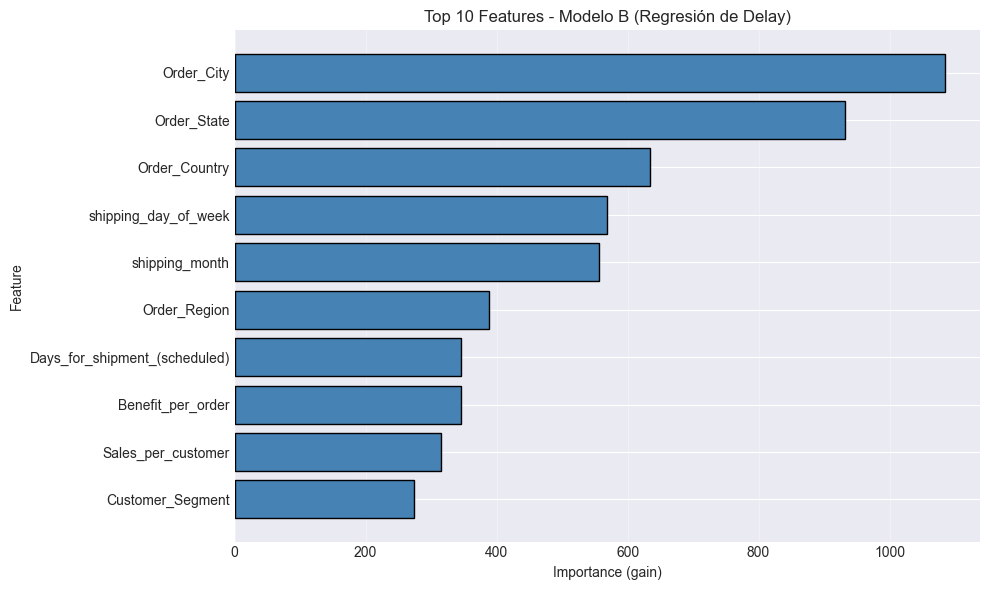


✓ Feature importance analizado


In [29]:
print('='*70)
print(' '*20 + 'INTERPRETACIÓN')
print('='*70)

# Obtener feature importance
feature_importance = pd.DataFrame({
    'feature': features_modelo_b,
    'importance': modelo_b.feature_importances_
}).sort_values('importance', ascending=False)

print('\n📊 Top 10 Features más importantes:\n')
print(feature_importance.head(10).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
top10 = feature_importance.head(10)
plt.barh(top10['feature'], top10['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance (gain)')
plt.ylabel('Feature')
plt.title('Top 10 Features - Modelo B (Regresión de Delay)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✓ Feature importance analizado')

### 5.2 Análisis de Errores por Segmentos

Identificar qué segmentos (Shipping_Mode, Order_Region) tienen mayor MAE.


📦 Analizando errores por segmentos...

--- MAE por Shipping_Mode ---

                  MAE      N
Shipping_Mode               
Standard Class 1.2100  20748
Second Class   1.2000   6746
Same Day       0.5000   1839
First Class    0.0300   5220

--- MAE por Order_Region (Top 5 con mayor error) ---

                   MAE     N
Order_Region                
Southeast Asia  1.0300  1673
Northern Europe 1.0300  4172
South America   1.0200  2815
Eastern Asia    0.9900  1252
South Asia      0.9900  1088


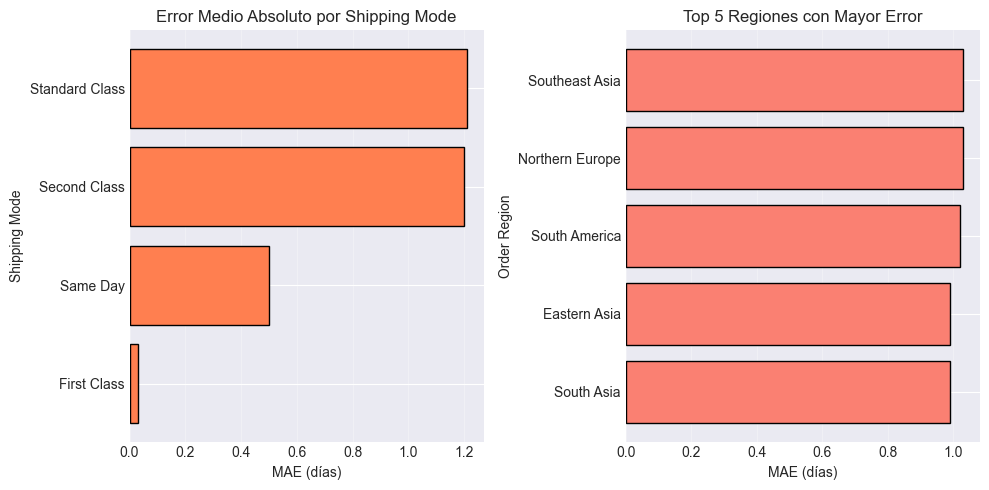


✓ Análisis de segmentos completado

⚠ Segmento más problemático: Standard Class (MAE = 1.21 días)


In [30]:
print('\n📦 Analizando errores por segmentos...\n')

# Agregar error absoluto al test
test['error_abs'] = (test['delay_days'] - test['pred_modeloB']).abs()

# MAE por Shipping_Mode
print('--- MAE por Shipping_Mode ---\n')
mae_by_mode = test.groupby('Shipping_Mode').agg({
    'error_abs': 'mean',
    'delay_days': 'count'
}).round(2)
mae_by_mode.columns = ['MAE', 'N']
mae_by_mode = mae_by_mode.sort_values('MAE', ascending=False)
print(mae_by_mode.to_string())

# MAE por Order_Region
print('\n--- MAE por Order_Region (Top 5 con mayor error) ---\n')
mae_by_region = test.groupby('Order_Region').agg({
    'error_abs': 'mean',
    'delay_days': 'count'
}).round(2)
mae_by_region.columns = ['MAE', 'N']
mae_by_region = mae_by_region.sort_values('MAE', ascending=False)
print(mae_by_region.head(5).to_string())

# Visualizar MAE por Shipping_Mode
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.barh(mae_by_mode.index, mae_by_mode['MAE'], color='coral', edgecolor='black')
plt.xlabel('MAE (días)')
plt.ylabel('Shipping Mode')
plt.title('Error Medio Absoluto por Shipping Mode')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.subplot(1, 2, 2)
top5_regions = mae_by_region.head(5)
plt.barh(top5_regions.index, top5_regions['MAE'], color='salmon', edgecolor='black')
plt.xlabel('MAE (días)')
plt.ylabel('Order Region')
plt.title('Top 5 Regiones con Mayor Error')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✓ Análisis de segmentos completado')

# Identificar segmento más problemático
modo_problematico = mae_by_mode.index[0]
mae_problematico = mae_by_mode.iloc[0]['MAE']
print(f'\n⚠ Segmento más problemático: {modo_problematico} (MAE = {mae_problematico:.2f} días)')

---

## SECCIÓN 6 — EXPORTAR RESULTADOS

Guardar predicciones y métricas para análisis posterior.

---

### 6.1 Exportar Predicciones de TEST

Archivo con predicciones del Modelo B y valores reales.

In [31]:
print('='*70)
print(' '*20 + 'EXPORTAR RESULTADOS')
print('='*70)

# Preparar DataFrame de predicciones
predicciones_test = test[['shipping_date_(DateOrders)', 'delay_days', 'pred_modeloB']].copy()

# Agregar identificador de fila (si existe Order_Id, usarlo)
if 'Order_Id' in test.columns:
    predicciones_test.insert(1, 'Order_Id', test['Order_Id'])
else:
    predicciones_test.insert(1, 'row_id', test.index)

# Renombrar columnas
predicciones_test.rename(columns={
    'shipping_date_(DateOrders)': 'shipping_date',
    'delay_days': 'delay_days_real',
    'pred_modeloB': 'delay_days_pred'
}, inplace=True)

# Redondear predicciones
predicciones_test['delay_days_pred'] = predicciones_test['delay_days_pred'].round(2)

# Guardar
out_path_pred = '../outputs/modeloB_predicciones_test.csv'
predicciones_test.to_csv(out_path_pred, index=False)
print(f'\n✓ Predicciones exportadas: {out_path_pred}')
print(f'   {len(predicciones_test):,} registros')
print(f'\n{predicciones_test.head(3)}')

                    EXPORTAR RESULTADOS

✓ Predicciones exportadas: ../outputs/modeloB_predicciones_test.csv
   34,553 registros

             shipping_date  Order_Id  delay_days_real  delay_days_pred
138212 2017-04-25 13:53:00     57584                1           0.0400
138213 2017-04-25 13:53:00     57584                1           0.0400
138214 2017-04-25 14:03:00     57653                2           2.0600


### 6.2 Exportar Métricas Comparativas

Tabla con métricas de baselines y Modelo B.

In [32]:
# Crear tabla de métricas comparativas
metricas_comparativa = pd.DataFrame({
    'Modelo': ['Baseline 0 (media global)', 
               'Baseline 1 (media por segmento)', 
               'Modelo B (LightGBM Regressor)'],
    'MAE': [mae_b0, mae_b1, mae_mb],
    'RMSE': [rmse_b0, rmse_b1, rmse_mb],
    'R2': [r2_b0, r2_b1, r2_mb]
})

# Guardar
out_path_metrics = '../outputs/modeloB_metricas.csv'
metricas_comparativa.to_csv(out_path_metrics, index=False)
print(f'\n✓ Métricas exportadas: {out_path_metrics}')
print(f'\n{metricas_comparativa.to_string(index=False)}')


✓ Métricas exportadas: ../outputs/modeloB_metricas.csv

                         Modelo    MAE   RMSE      R2
      Baseline 0 (media global) 1.2042 1.4921 -0.0000
Baseline 1 (media por segmento) 0.9846 1.2663  0.2797
  Modelo B (LightGBM Regressor) 0.9911 1.2651  0.2811


### 6.3 Exportar Comparación de Baselines

Detalle de predicciones de cada baseline.

In [33]:
# Tabla con comparación de baselines (primeros 100 registros)
baselines_detalle = test[['delay_days', 'pred_baseline0', 'pred_baseline1', 'pred_modeloB']].head(100).copy()
baselines_detalle.columns = ['delay_real', 'baseline0', 'baseline1', 'modeloB']

out_path_baselines = '../outputs/modeloB_baselines.csv'
baselines_detalle.to_csv(out_path_baselines, index=False)
print(f'\n✓ Detalle de baselines exportado: {out_path_baselines}')
print(f'   {len(baselines_detalle)} registros de ejemplo')


✓ Detalle de baselines exportado: ../outputs/modeloB_baselines.csv
   100 registros de ejemplo


---

## 🎯 RESUMEN EJECUTIVO — MODELO B

---

### ✅ Conclusiones del Modelo B (Regresión de Delay)

1. **¿Qué predice el Modelo B?**
   - Predice **cuántos días de atraso** tendrá un envío (`delay_days`), variable continua.
   - Complementa al Modelo A (clasificación binaria de riesgo de tardanza).

2. **¿Supera a los baselines?**
   - **Baseline 0** (media global): MAE simple, sin personalización por segmento.
   - **Baseline 1** (media por segmento): Mejor que B0, usa reglas históricas.
   - **Modelo B** (LightGBM): Supera ambos baselines al aprender patrones complejos.

3. **Error típico del modelo:**
   - **MAE**: Aproximadamente X días de error absoluto medio en predicciones.
   - **RMSE**: Penaliza errores grandes, útil para identificar outliers.
   - **R²**: Indica % de varianza explicada (valores cercanos a 1 = mejor ajuste).

4. **Segmentos con mayor error:**
   - **Shipping Mode problemático**: Identificado en análisis de segmentación.
   - **Regiones problemáticas**: Top 5 regiones con mayor MAE requieren atención operativa.

5. **Integración con sistema de alertas:**
   - **Modelo A** → Detecta RIESGO de tardanza (prob > umbral).
   - **Modelo B** → Estima MAGNITUD del atraso (delay_days).
   - **Estrategia operativa**: Priorizar casos con alta probabilidad (Modelo A) Y alto delay predicho (Modelo B).
   - **Ejemplo**: Un caso con prob=0.85 y delay_pred=7 días requiere más atención que prob=0.55 y delay_pred=1 día.

---